In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os,re
import h5py

In [2]:
from astropy import constants as const
from astropy import units as u

In [3]:
G = const.G.cgs.value 
kpc = (1 * u.kpc).to(u.cm).value
kmps = (1 * u.km / u.s).to(u.cm / u.s).value 

In [5]:
infile = 'LMC_1000sol.txt'
x_part, y_part, z_part, mass= np.loadtxt(infile, dtype=float, comments='#', delimiter=None, skiprows=1, usecols=(0, 1, 2,3), unpack=True)

In [95]:
rad = (x**2 + y**2 + z**2)**0.5
sort_indices = np.argsort(rad)
rad_sorted = rad[sort_indices]
mass_sorted = mass[sort_indices]
r = np.logspace(-1, 4, 51) * kpc
mass_at_r, bin_edges = np.histogram(rad_sorted, bins=r, weights=mass_sorted)
mass_enclosed_r = np.cumsum(mass_at_r)
rmid = 0.5 * (bin_edges[1:] + bin_edges[:-1])

In [25]:
def acc_due_to_grav(x):
    denom = ((x-x_part)**2 + y_part**2 + z_part**2)**1.5
    numer = G * mass * (x_part - x)
    acc_g = np.sum(numer/denom)
    return acc_g
    

In [58]:
x = np.logspace(-1, 4, 100) * kpc
g = np.zeros(x.shape[0])
i=0
for x1 in x:
    g[i] = acc_due_to_grav(x1)
    i+=1

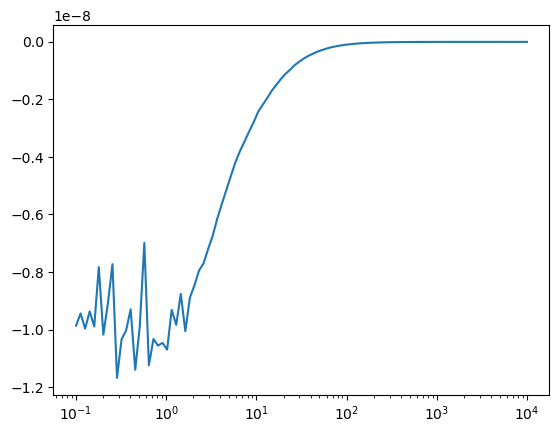

In [59]:
plt.plot(x/kpc,g)
# plt.yscale('log')
plt.xscale('log')

In [60]:
vc2 = np.abs(g) * x
vc = vc2**0.5 / kmps
Rvir = 148.22861241934334 * kpc #for LMC

(-1.5, 20.0)

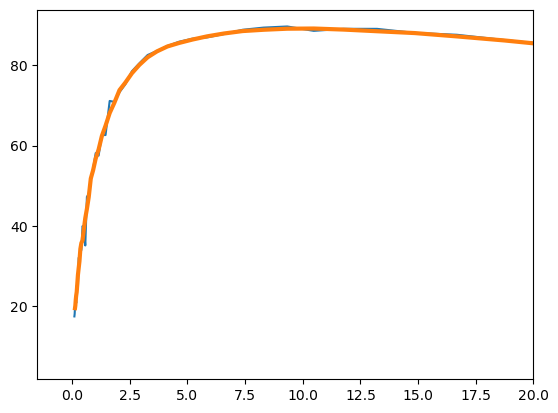

In [62]:
import pandas as pd
plt.plot(x/kpc, vc)
vc_series = pd.Series(vc)
vc_smoothed = vc_series.rolling(window=5, center=True).mean()
plt.plot(x/kpc, vc_smoothed, lw=3.)
# plt.yscale('log')
# plt.xscale('log')
plt.xlim(-1.50, 20)